In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import PolynomialFeatures


In [5]:
df = pd.read_excel("../Dataset/Houseprice_dataset.xlsx")

df.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


# 🏠 House Price Prediction using Linear Regression

### Project Objective
The aim of this project is to predict **house price in INR** using house-related features such as area, bedrooms, bathrooms, location score, age, distance from city, lot size, garage, pool and renovation age.

### Algorithm Used
**Linear Regression**

### Dataset
`RealEstate_HousePrice_Dataset_4.xlsx`

# 📊 PART-A : Conceptual Understanding (Theory)

## Question 1: What are Supervised Learning Algorithms?

**Answer:**  
Supervised Learning is a type of Machine Learning in which the model learns from data where the input and correct output are already given.  
Examples are **Linear Regression, Logistic Regression and Decision Tree**.

## Question 2: Difference between Regression Algorithms vs Classification Algorithms

**Answer:**  
Regression algorithms predict a **continuous numerical value**, such as house price or salary.  
Classification algorithms predict a **category or class**, such as Pass/Fail or Yes/No.

## Question 3: Explain Linear Regression

**Answer:**  
Linear Regression is a supervised learning algorithm used to predict a continuous value.  
It finds the relationship between input variables and the target variable using a linear equation.

## Question 4: List and explain the Assumptions of Linear Regression

**Answer:**  
The main assumptions of Linear Regression are:

1. There should be a linear relationship between input and target.
2. Observations should be independent.
3. Residuals should have nearly constant variance.
4. Residuals should be approximately normally distributed.
5. Input variables should not have very high multicollinearity.

## Question 5: What is Bias–Variance Trade-Off?

**Answer:**  
**Bias** is the error caused when a model is too simple. **Variance** is the error caused when a model is too sensitive to the training data.  
A good model tries to maintain a proper balance between bias and variance.

## Question 6: Explain Overfitting and Underfitting with Examples

**Answer:**  
**Overfitting** happens when a model learns the training data too closely and performs poorly on new data.  
**Underfitting** happens when a model is too simple and performs poorly on both training and testing data.

**Example:**  
If a model performs very well on training data but poorly on testing data, it is **overfitting**.

# 📊 PART-B : Dataset Understanding & Preparation

### Task 7 — Independent and Dependent Variables


In [ ]:
# Independent and dependent variables

X = df.drop(columns=["house_id", "house_price_inr"])
y = df["house_price_inr"]

print("Independent Variables:")
print(X.columns.tolist())

print("\nDependent Variable:")
print(y.name)

Independent Variables:
['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'age_years', 'distance_city_km', 'lot_size_sqft', 'has_garage', 'has_pool', 'renovation_years_ago']

Dependent Variable:
house_price_inr


## Conclusion

The independent variables are the house features, and **house_price_inr** is the dependent variable.

### Task 8 — Visualize Relationships Between Features and Target Variable

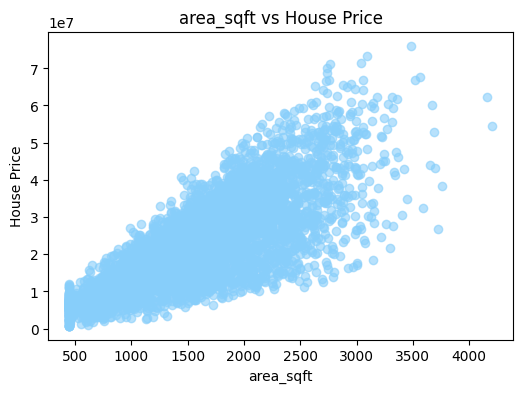

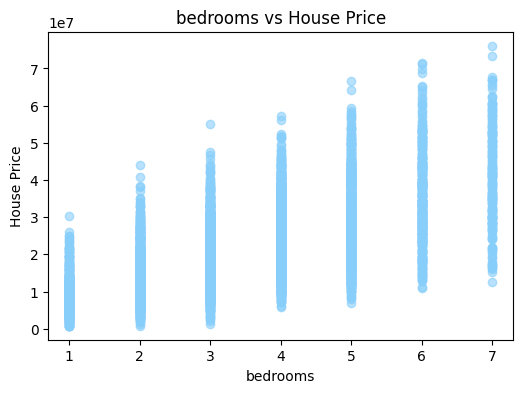

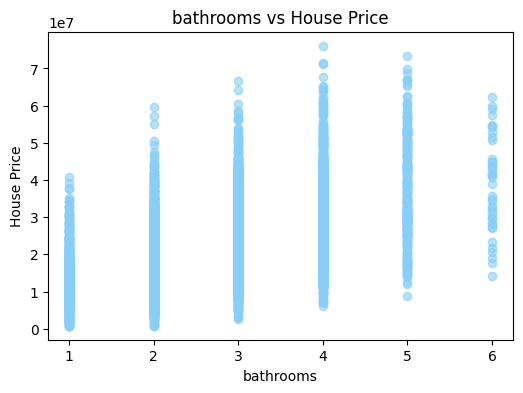

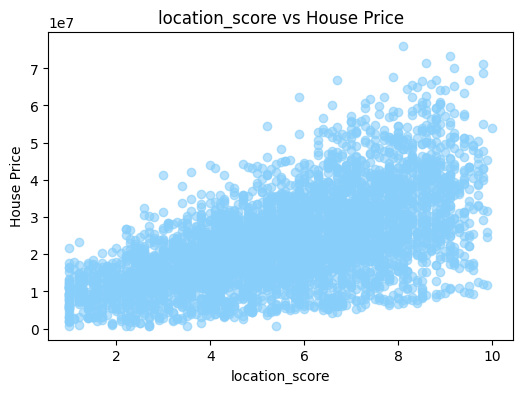

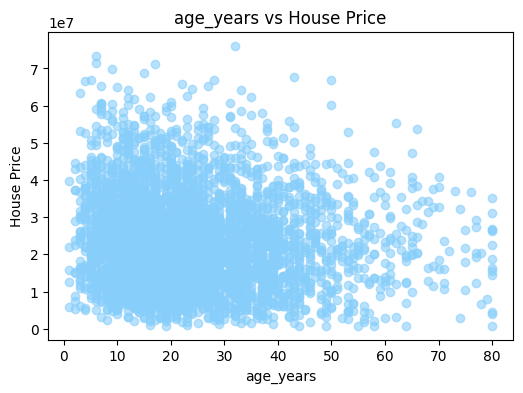

In [23]:
# Visualize relationships between features and house price

features = ["area_sqft", "bedrooms", "bathrooms", "location_score", "age_years"]

for feature in features:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[feature], df["house_price_inr"], color='LightSkyBlue', alpha=0.6)
    plt.xlabel(feature)
    plt.ylabel("House Price")
    plt.title(feature + " vs House Price")
    plt.show()

## Conclusion

The plots show the relationship between house features and **house price**.

### Task 9 — Split the Dataset into Training and Testing Sets

In [21]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3360, 10)
Testing data: (840, 10)


## Conclusion

The dataset was split into **80% training data** and **20% testing data**.

# 📊 PART-C : Simple Linear Regreesion

### Task 10 - Implement Simple Linear Regression

In [ ]:
X = df[["area_sqft"]]
y = df["house_price_inr"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

# print("Model trained successfully.")

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[14788.31]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['area_sqft']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.164e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


## Conclusion

Simple Linear Regression was successfully implemented using **area_sqft** to predict house price.

### Task 11 - Plot Regression Line and Interpret Slope and Intercept

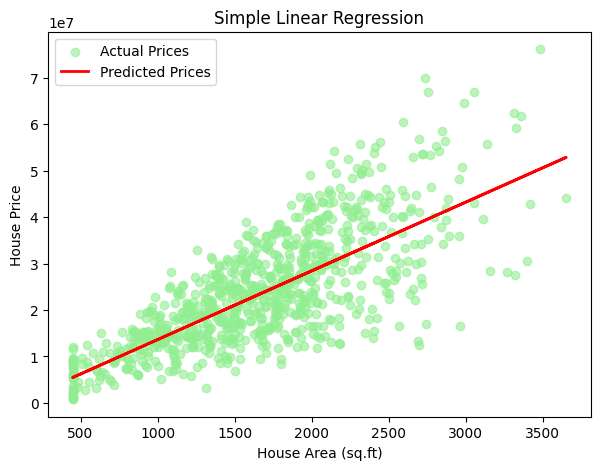

Slope: 14788.306111307536
Intercept: -1163519.1764186025


In [39]:
y_pred = model.predict(X_test)

plt.figure(figsize=(7, 5))
plt.scatter(X_test, y_test, color='Lightgreen', alpha=0.6, label='Actual Prices')
plt.plot(X_test, y_pred, color='Red', linewidth=2, label='Predicted Prices')
plt.xlabel("House Area (sq.ft)")
plt.ylabel("House Price")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

## Conclusion

The regression line shows the relationship between **house area and house price**.  
The slope shows how house price changes when area increases.

### TASK 12 - Validate Linear Regression Assumptions

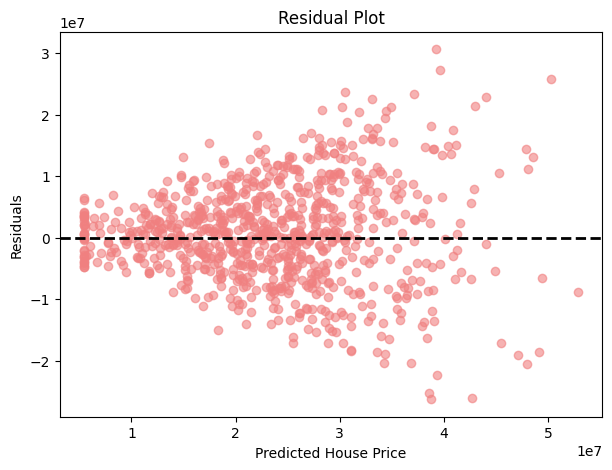

In [45]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, color='Lightcoral', alpha=0.6)
plt.axhline(0, color='black', linestyle='--', linewidth=2)
plt.xlabel("Predicted House Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

## Conclusion

The residuals are checked around zero using the residual plot.  
This helps us understand whether the linear regression assumption is reasonable.

# 📊 PART D : Model Evaluation Matrics

### Task 13 - Evaluate the Simple Linear Regression Model

In [47]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

n = len(y_test)
p = X_test.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)
print("Adjusted R² Score:", adjusted_r2)

Mean Squared Error (MSE): 66989260021849.47
Mean Absolute Error (MAE): 6294593.696131912
Root Mean Squared Error (RMSE): 8184696.696997969
R² Score: 0.5625199587991578
Adjusted R² Score: 0.5619979062440257


## Conclusion

The model was evaluated using **MSE, MAE, RMSE, R² Score and Adjusted R² Score** to measure its performance.

## Task 14: Interpretation of Model Evaluation Metrics

**MSE:** Measures the average squared prediction error. Lower MSE indicates better performance.

**MAE:** Shows the average absolute error between actual and predicted prices. Lower MAE is better.

**RMSE:** Shows the average prediction error in the same unit as house price. Lower RMSE is better.

**R² Score:** Shows how much variation in house price is explained by the model. A value closer to 1 indicates better performance.

**Adjusted R² Score:** Similar to R² but also considers the number of features used in the model.

## Conclusion

These metrics help us understand the accuracy and overall performance of the Simple Linear Regression model.

# 📊 PART-E : Multiple Linear Regression 

### Task 15 - Implement Multiple Linear Regression

In [51]:
# Use all relevant features
X = df.drop(columns=["house_id", "house_price_inr"])
y = df["house_price_inr"]

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X, y, test_size=0.20, random_state=42
)

multi_model = LinearRegression()
multi_model.fit(X_train_multi, y_train_multi)

multi_pred = multi_model.predict(X_test_multi)

print("Multiple Linear Regression model trained successfully.")

Multiple Linear Regression model trained successfully.


## Conclusion

Multiple Linear Regression was implemented using all relevant features to predict house price.

### Task 16 - Compare Multiple Regression with Simple Regression

In [53]:
simple_r2 = r2_score(y_test, y_pred)
multi_r2 = r2_score(y_test_multi, multi_pred)

simple_mae = mean_absolute_error(y_test, y_pred)
multi_mae = mean_absolute_error(y_test_multi, multi_pred)

print("Simple Linear Regression")
print("R² Score:", simple_r2)
print("MAE:", simple_mae)

print("\nMultiple Linear Regression")
print("R² Score:", multi_r2)
print("MAE:", multi_mae)

Simple Linear Regression
R² Score: 0.5625199587991578
MAE: 6294593.696131912

Multiple Linear Regression
R² Score: 0.917760687750989
MAE: 2604991.406155695


## Conclusion
Multiple Linear Regression can use more information than Simple Linear Regression, so its performance can improve.

### Task 17 - Explain Why Performance Improves or Degrades

##### Explanation

Multiple Linear Regression can improve performance because it uses several relevant features together.

For example, house area, bedrooms, bathrooms and location score can all help predict house price.

If irrelevant or highly related features are added, the model may not improve and can become less reliable.

# 📊 PART F: Polynomial Regression

### Task 18 - Implement Polynomial Regression

In [57]:
X = df[["area_sqft"]]
y = df["house_price_inr"]

X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X, y, test_size=0.20, random_state=42
)

poly = PolynomialFeatures(degree=2)

X_train_poly_new = poly.fit_transform(X_train_poly)
X_test_poly_new = poly.transform(X_test_poly)

poly_model = LinearRegression()
poly_model.fit(X_train_poly_new, y_train_poly)

poly_pred = poly_model.predict(X_test_poly_new)

print("Polynomial Regression model trained successfully.")

Polynomial Regression model trained successfully.


## Conclusion

Polynomial Regression with **degree 2** was successfully implemented using house area.

### Task 19 - Compare Linear vs Polynomial Regression

In [58]:
linear_r2 = r2_score(y_test, y_pred)
poly_r2 = r2_score(y_test_poly, poly_pred)

print("Linear Regression R² Score:", linear_r2)
print("Polynomial Regression R² Score:", poly_r2)

Linear Regression R² Score: 0.5625199587991578
Polynomial Regression R² Score: 0.5626917978136475


c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


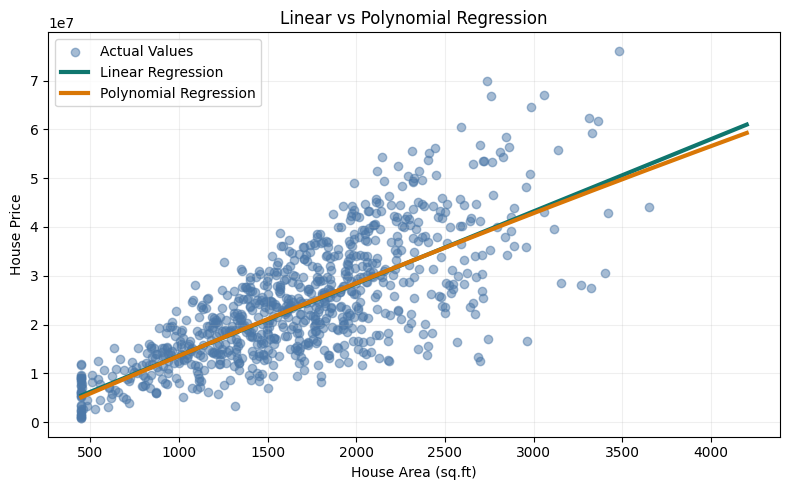

In [59]:
import numpy as np

X_plot = np.linspace(
    X["area_sqft"].min(),
    X["area_sqft"].max(),
    300
).reshape(-1, 1)

y_linear_plot = model.predict(X_plot)

X_plot_poly = poly.transform(X_plot)
y_poly_plot = poly_model.predict(X_plot_poly)

plt.figure(figsize=(8, 5))

plt.scatter(
    X_test_poly,
    y_test_poly,
    color="#4C78A8",
    alpha=0.5,
    label="Actual Values"
)

plt.plot(
    X_plot,
    y_linear_plot,
    color="#0F766E",
    linewidth=3,
    label="Linear Regression"
)

plt.plot(
    X_plot,
    y_poly_plot,
    color="#D97706",
    linewidth=3,
    label="Polynomial Regression"
)

plt.xlabel("House Area (sq.ft)")
plt.ylabel("House Price")
plt.title("Linear vs Polynomial Regression")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Conclusion
The graph shows the difference between the **linear** and **polynomial** regression models.  
The R² scores help compare their numerical performance.

### Task 20 - Identify Overfitting or Underfitting

In [60]:
train_r2_poly = poly_model.score(X_train_poly_new, y_train_poly)
test_r2_poly = poly_model.score(X_test_poly_new, y_test_poly)

print("Training R²:", train_r2_poly)
print("Testing R²:", test_r2_poly)

Training R²: 0.5724674245504779
Testing R²: 0.5626917978136475


## Conclusion

If the training R² is much higher than the testing R², it may indicate **overfitting**.

If both training and testing R² scores are low, it may indicate **underfitting**.

A small difference between training and testing scores indicates better generalization.

# 📊 PART G : Gradient Descent Optimization

### Task 21 - Explain Gradient Descent Conceptually

####  Gradient Descent – Concept

Gradient Descent is an optimization method used to reduce the model's error.

It changes the model parameters step-by-step in the direction that reduces the error.
The process continues until the error becomes minimum or nearly stable.

### Task 22 - Implement Batch Gradient Descent from Scratch

In [61]:
import time

# Use area_sqft as feature
X_gd = df["area_sqft"].values
y_gd = df["house_price_inr"].values

# Standardize feature
X_gd = (X_gd - X_gd.mean()) / X_gd.std()

# Initial values
w = 0
b = 0
learning_rate = 0.01
epochs = 1000

batch_losses = []

start = time.time()

for i in range(epochs):
    y_pred_gd = w * X_gd + b

    error = y_pred_gd - y_gd

    dw = (2 / len(X_gd)) * np.sum(error * X_gd)
    db = (2 / len(X_gd)) * np.sum(error)

    w = w - learning_rate * dw
    b = b - learning_rate * db

    loss = np.mean(error ** 2)
    batch_losses.append(loss)

batch_time = time.time() - start

print("Batch Gradient Descent completed.")
print("Training Time:", batch_time)

Batch Gradient Descent completed.
Training Time: 0.0882577896118164


## Conclusion

Batch Gradient Descent was implemented from scratch using the complete dataset in each iteration.

### Task 23 - Implement Stochastic Gradient Descent (SGD)

In [62]:
# Initial values
w = 0
b = 0
learning_rate = 0.0001
epochs = 50

sgd_losses = []

start = time.time()

for i in range(epochs):
    total_error = 0

    for j in range(len(X_gd)):
        y_pred_sgd = w * X_gd[j] + b
        error = y_pred_sgd - y_gd[j]

        dw = 2 * error * X_gd[j]
        db = 2 * error

        w = w - learning_rate * dw
        b = b - learning_rate * db

        total_error += error ** 2

    sgd_losses.append(total_error / len(X_gd))

sgd_time = time.time() - start

print("Stochastic Gradient Descent completed.")
print("Training Time:", sgd_time)

Stochastic Gradient Descent completed.
Training Time: 0.5828766822814941


## Conclusion

Stochastic Gradient Descent updates the model using one data point at a time.

### Task 24 - Implement Mini-Batch Gradient Descent

In [63]:
# Initial values
w = 0
b = 0
learning_rate = 0.01
epochs = 100
batch_size = 32

mini_losses = []

start = time.time()

for i in range(epochs):
    indices = np.random.permutation(len(X_gd))
    X_shuffled = X_gd[indices]
    y_shuffled = y_gd[indices]

    total_error = 0

    for j in range(0, len(X_gd), batch_size):
        X_batch = X_shuffled[j:j + batch_size]
        y_batch = y_shuffled[j:j + batch_size]

        y_pred_batch = w * X_batch + b
        error = y_pred_batch - y_batch

        dw = (2 / len(X_batch)) * np.sum(error * X_batch)
        db = (2 / len(X_batch)) * np.sum(error)

        w = w - learning_rate * dw
        b = b - learning_rate * db

        total_error += np.mean(error ** 2)

    mini_losses.append(total_error)

mini_time = time.time() - start

print("Mini-Batch Gradient Descent completed.")
print("Training Time:", mini_time)

Mini-Batch Gradient Descent completed.
Training Time: 0.5025272369384766


## Conclusion

Mini-Batch Gradient Descent updates the model using small groups of data points.

### Task 25 - Compare Convergence Behavior and Training Time

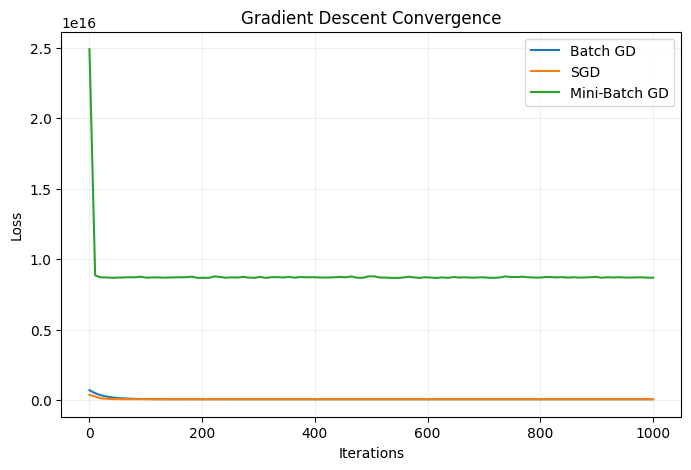

Batch GD Time: 0.0882577896118164
SGD Time: 0.5828766822814941
Mini-Batch GD Time: 0.5025272369384766


In [64]:
plt.figure(figsize=(8, 5))

plt.plot(batch_losses, label="Batch GD")
plt.plot(
    np.linspace(0, len(batch_losses), len(sgd_losses)),
    sgd_losses,
    label="SGD"
)
plt.plot(
    np.linspace(0, len(batch_losses), len(mini_losses)),
    mini_losses,
    label="Mini-Batch GD"
)

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Gradient Descent Convergence")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print("Batch GD Time:", batch_time)
print("SGD Time:", sgd_time)
print("Mini-Batch GD Time:", mini_time)

## Conclusion

The three methods show different convergence behavior and training times.  
Batch GD is stable, SGD updates quickly, and Mini-Batch GD provides a balance between the two.

# 📊 PART H : Bias–Variance & Model Diagnostics

### Task 26 - Analyze Bias and Variance

In [65]:
# Simple Linear Regression
simple_train_r2 = model.score(X_train, y_train)
simple_test_r2 = model.score(X_test, y_test)

# Multiple Linear Regression
multi_train_r2 = multi_model.score(X_train_multi, y_train_multi)
multi_test_r2 = multi_model.score(X_test_multi, y_test_multi)

# Polynomial Regression
poly_train_r2 = poly_model.score(X_train_poly_new, y_train_poly)
poly_test_r2 = poly_model.score(X_test_poly_new, y_test_poly)

print("Simple Linear Regression")
print("Train R²:", simple_train_r2)
print("Test R² :", simple_test_r2)

print("\nMultiple Linear Regression")
print("Train R²:", multi_train_r2)
print("Test R² :", multi_test_r2)

print("\nPolynomial Regression")
print("Train R²:", poly_train_r2)
print("Test R² :", poly_test_r2)

Simple Linear Regression
Train R²: 0.5723074839148459
Test R² : 0.5625199587991578

Multiple Linear Regression
Train R²: 0.9247216651865339
Test R² : 0.917760687750989

Polynomial Regression
Train R²: 0.5724674245504779
Test R² : 0.5626917978136475


## Conclusion

Training and testing R² scores were compared for Simple, Multiple and Polynomial Regression to understand model bias and variance.

### Task 27 - Explain How Model Complexity Affects Prediction Error

A simple model may have high bias because it cannot capture complex relationships.

As model complexity increases, training error usually decreases.

However, a very complex model can overfit the training data and increase testing error.

### Task 28 - Identify Which Model Best Balances Bias and Variance

In [66]:
print("Simple Regression - Train:", simple_train_r2, "Test:", simple_test_r2)
print("Multiple Regression - Train:", multi_train_r2, "Test:", multi_test_r2)
print("Polynomial Regression - Train:", poly_train_r2, "Test:", poly_test_r2)

Simple Regression - Train: 0.5723074839148459 Test: 0.5625199587991578
Multiple Regression - Train: 0.9247216651865339 Test: 0.917760687750989
Polynomial Regression - Train: 0.5724674245504779 Test: 0.5626917978136475


## 28. Model Selection

The model with a good testing R² score and a small difference between training and testing R² generally provides a better balance between bias and variance.

Among the three models, the model showing this behavior can be considered the best-balanced model.

## Conclusion

The model with a good test score and a small train-test difference provides the best bias-variance balance.

# 📊 PART I : Final Analysis & Reporting

### Task 29 - Summarize Findings in a Short Report

In [67]:
# Final model comparison

results = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression",
        "Polynomial Regression"
    ],
    "Train R2": [
        simple_train_r2,
        multi_train_r2,
        poly_train_r2
    ],
    "Test R2": [
        simple_test_r2,
        multi_test_r2,
        poly_test_r2
    ]
})

results

,Model,Train R2,Test R2
0,Simple Linear Regression,0.572307,0.562520
1,Multiple Linear Regression,0.924722,0.917761
2,Polynomial Regression,0.572467,0.562692


In [68]:
best_model = results.loc[results["Test R2"].idxmax(), "Model"]

print("Best Performing Model:", best_model)

Best Performing Model: Multiple Linear Regression


## 29. Final Analysis

### Best-Performing Model
The model with the highest **Test R² Score** is considered the best-performing model because it explains more variation in unseen data.

### Gradient Descent
Gradient Descent optimization reduces the model's error step-by-step. Batch, Stochastic and Mini-Batch Gradient Descent show different convergence behavior.

### Overfitting and Underfitting
Training and testing R² scores were compared to identify possible overfitting or underfitting.

### Business Interpretation
House area and other house-related features can help predict house prices. The model can support better understanding of property pricing and decision-making.

## Conclusion

The models were compared using their performance, optimization behavior and train-test scores. The model with the best test performance is selected as the final model.

# Final Conclusion

This project used Linear Regression techniques to predict house prices.

Simple, Multiple and Polynomial Regression were implemented and compared using different evaluation metrics.

Gradient Descent was also implemented using Batch, Stochastic and Mini-Batch methods.

The final model was selected based on its testing performance and its ability to generalize to unseen data.